<a href="https://colab.research.google.com/github/RicardoTL75/Module_4_Deep_Learning/blob/Marios_file/COCO_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Talento Altamente Especializado – Inteligencia Artificial 2026 COCYTEN-Nayarit

Lab: Implement and evaluate a Neural Network for segmentation and object detection using COCO

Instructor: M.Sc. Mario Ivan Lopez Valdovinos

Assignment Date: 24/07/2026

Student: Ricardo Torres López


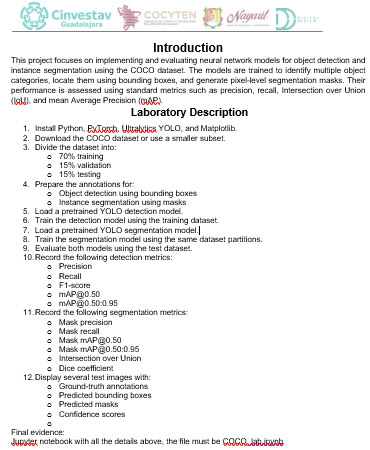

Install the required packages (PyTorch, Python y Matplotlib
which are available for Google Colab).

In [1]:
!pip install -q ultralytics pycocotools

import os
import random
import shutil
import zipfile
import json as pyjson

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import torch

from ultralytics import YOLO

# Use one seed for repeatable results para la partición del
# for the data split and training.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DEVICE = 0 if torch.cuda.is_available() else "cpu"
print(f"PyTorch {torch.__version__} | GPU disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Dispositivo: {torch.cuda.get_device_name(0)}")
else:
    print("ADVERTENCIA: no se detectó GPU. Actívela en "
          "Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 618.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch 2.11.0+cpu | GPU disponible: False
ADVERTENCIA: no se detectó GPU. Actívela en Entorno de ejecución > Cambiar tipo de entorno de ejecución > GPU.


The complete COCO dataset is large, so this laboratory uses **COCO128** and **COCO128-seg** from Ultralytics.

Both versions use the same 128 images. COCO128 provides bounding-box labels, while COCO128-seg provides polygon labels for instance segmentation.

Using these small official subsets makes the experiment faster while keeping the original COCO classes.

In [2]:
# Download the official COCO subsets COCO128 (detección) y COCO128-seg
# for detection and instance segmentation.
# Both subsets use the same 128 COCO images.
WORKSPACE = "/content/coco_lab_data"
os.makedirs(WORKSPACE, exist_ok=True)

DOWNLOADS = {
    "coco128": "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128.zip",
    "coco128-seg": "https://github.com/ultralytics/assets/releases/download/v0.0.0/coco128-seg.zip",
}

for name, url in DOWNLOADS.items():
    zip_path = os.path.join(WORKSPACE, f"{name}.zip")
    if not os.path.isdir(os.path.join(WORKSPACE, name)):
        print(f"Descargando {name}...")
        torch.hub.download_url_to_file(url, zip_path, progress=True)
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(WORKSPACE)
        os.remove(zip_path)
    else:
        print(f"{name} ya se encuentra disponible localmente.")

DET_IMAGES = os.path.join(WORKSPACE, "coco128", "images", "train2017")
DET_LABELS = os.path.join(WORKSPACE, "coco128", "labels", "train2017")
SEG_IMAGES = os.path.join(WORKSPACE, "coco128-seg", "images", "train2017")
SEG_LABELS = os.path.join(WORKSPACE, "coco128-seg", "labels", "train2017")

IMAGE_COUNT = len([f for f in os.listdir(DET_IMAGES) if f.lower().endswith(".jpg")])
print(f"Total de imágenes disponibles: {IMAGE_COUNT}")

Descargando coco128...


100%|██████████| 6.66M/6.66M [00:00<00:00, 25.3MB/s]


Descargando coco128-seg...


100%|██████████| 6.79M/6.79M [00:00<00:00, 24.3MB/s]


Total de imágenes disponibles: 128


The 128 common images are randomly divided into:

- **70% train**
- **15% validation**
- **15% test**

The same assignment is used for detection and segmentation. A fixed seed makes the split repeatable.

In [4]:
def split_dataset(image_dir, label_dir, output_root, names, assignment):
    for part in ("train", "val", "test"):
        os.makedirs(os.path.join(output_root, "images", part), exist_ok=True)
        os.makedirs(os.path.join(output_root, "labels", part), exist_ok=True)

    for stem in names:
        part = assignment[stem]

        image_source = os.path.join(image_dir, stem + ".jpg")
        label_source = os.path.join(label_dir, stem + ".txt")

        image_target = os.path.join(
            output_root, "images", part, stem + ".jpg"
        )
        label_target = os.path.join(
            output_root, "labels", part, stem + ".txt"
        )

        if os.path.exists(image_source):
            shutil.copy2(image_source, image_target)

        if os.path.exists(label_source):
            shutil.copy2(label_source, label_target)


# Output folders for each YOLO task
DETECTION_DATA = os.path.join(WORKSPACE, "detection_data")
SEGMENTATION_DATA = os.path.join(WORKSPACE, "segmentation_data")

stems = sorted(
    os.path.splitext(name)[0]
    for name in os.listdir(DET_IMAGES)
    if name.lower().endswith(".jpg")
)

shuffled = stems.copy()
random.Random(SEED).shuffle(shuffled)

n = len(shuffled)
n_train = round(n * 0.70)
n_val = round(n * 0.15)

train_names = shuffled[:n_train]
val_names = shuffled[n_train:n_train + n_val]
test_names = shuffled[n_train + n_val:]

split_assignment = {}

for stem in train_names:
    split_assignment[stem] = "train"

for stem in val_names:
    split_assignment[stem] = "val"

for stem in test_names:
    split_assignment[stem] = "test"

n_test = len(test_names)

print(
    f"Images: {n} | train: {n_train} | "
    f"val: {n_val} | test: {n_test}"
)

split_dataset(
    DET_IMAGES,
    DET_LABELS,
    DETECTION_DATA,
    stems,
    split_assignment
)

split_dataset(
    SEG_IMAGES,
    SEG_LABELS,
    SEGMENTATION_DATA,
    stems,
    split_assignment
)

summary_rows = []

for root, task in (
    (DETECTION_DATA, "Detection"),
    (SEGMENTATION_DATA, "Segmentation")
):
    for part in ("train", "val", "test"):
        image_count = len(
            os.listdir(os.path.join(root, "images", part))
        )
        label_count = len(
            os.listdir(os.path.join(root, "labels", part))
        )

        summary_rows.append({
            "Task": task,
            "Split": part,
            "Images": image_count,
            "Labels": label_count
        })

pd.DataFrame(summary_rows)


Images: 128 | train: 90 | val: 19 | test: 19


,Task,Split,Images,Labels
0,Detection,train,90,88
1,Detection,val,19,19
2,Detection,test,19,19
3,Segmentation,train,90,88
4,Segmentation,val,19,19
5,Segmentation,test,19,19


Labels and dataset configuration

YOLO needs a class list and the location of the train, validation, and test images.

In [5]:
CLASS_NAMES = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck",
    "boat", "traffic light", "fire hydrant", "stop sign", "parking meter", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra",
    "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
    "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse",
    "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink",
    "refrigerator", "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush",
]
assert len(CLASS_NAMES) == 80


def write_data_yaml(path, root, names):
    names_block = "\n".join(f"  {i}: {n}" for i, n in enumerate(names))
    content = (
        f"path: {root}\n"
        f"train: images/train\n"
        f"val: images/val\n"
        f"test: images/test\n"
        f"names:\n{names_block}\n"
    )
    with open(path, "w") as f:
        f.write(content)


DETECTION_YAML = os.path.join(WORKSPACE, "data_detect.yaml")
SEGMENTATION_YAML = os.path.join(WORKSPACE, "data_seg.yaml")
write_data_yaml(DETECTION_YAML, DETECTION_DATA, CLASS_NAMES)
write_data_yaml(SEGMENTATION_YAML, SEGMENTATION_DATA, CLASS_NAMES)

print(open(DETECTION_YAML).read())

path: /content/coco_lab_data/detection_data
train: images/train
val: images/val
test: images/test
names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
  13: bench
  14: bird
  15: cat
  16: dog
  17: horse
  18: sheep
  19: cow
  20: elephant
  21: bear
  22: zebra
  23: giraffe
  24: backpack
  25: umbrella
  26: handbag
  27: tie
  28: suitcase
  29: frisbee
  30: skis
  31: snowboard
  32: sports ball
  33: kite
  34: baseball bat
  35: baseball glove
  36: skateboard
  37: surfboard
  38: tennis racket
  39: bottle
  40: wine glass
  41: cup
  42: fork
  43: knife
  44: spoon
  45: bowl
  46: banana
  47: apple
  48: sandwich
  49: orange
  50: broccoli
  51: carrot
  52: hot dog
  53: pizza
  54: donut
  55: cake
  56: chair
  57: couch
  58: potted plant
  59: bed
  60: dining table
  61: toilet
  62: tv
  63: laptop
  64: mouse
  65: remote
  66: k

Detection model

The detection model is **YOLOv8n**. The nano version is small and fast, which is useful for a Colab experiment.

The model starts from pre-trained COCO weights instead of random weights.

In [6]:
detector = YOLO("yolov8n.pt")

Detection training

The detection model is fine-tuned for 50 epochs with early stopping.

Main settings:

- Image size: 640
- Batch size: 16
- Patience: 15
- Fixed seed for repeatability

In [7]:
det_train = detector.train(
    data=DETECTION_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    seed=SEED,
    device=DEVICE,
    project="/content/runs",
    name="detect_train",
    verbose=True,
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco_lab_data/data_detect.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=detect_train, nbs=64, nms=Fal

Instance segmentation model. The second model is **YOLOv8n-seg**. It predicts object masks in addition to object classes and boxes.

In [8]:
segmenter = YOLO("yolov8n-seg.pt")

seg_train = segmenter.train(
    data=SEGMENTATION_YAML,
    epochs=50,
    imgsz=640,
    batch=16,
    patience=15,
    seed=SEED,
    device=DEVICE,
    project="/content/runs",
    name="seg_train",
    verbose=True,
)

Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/coco_lab_data/data_seg.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seg_train, nbs=64, nms=False

Test evaluation: Reports Precision, Recall, F1-score, mAP@0.50, and mAP@0.50:0.95. These values show how well the models find and locate objects.

In [9]:
det_test = detector.val(
    data=DETECTION_YAML, split="test", device=DEVICE
)
det_values = det_test.results_dict

precision_det = det_values["metrics/precision(B)"]
recall_det = det_values["metrics/recall(B)"]
map50_det = det_values["metrics/mAP50(B)"]
map5095_det = det_values["metrics/mAP50-95(B)"]

def f1_score(precision, recall):
    return 2 * precision * recall / (precision + recall + 1e-16)

f1_det = f1_score(precision_det, recall_det)

print("Detection metrics — test set")
for name, value in (
    ("Precision", precision_det),
    ("Recall", recall_det),
    ("F1-score", f1_det),
    ("mAP@0.50", map50_det),
    ("mAP@0.50:0.95", map5095_det),
):
    print(f"  {name:12s}: {value:.4f}")


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 37.0±23.0 MB/s, size: 72.5 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/coco_lab_data/detection_data/labels/test... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 511.1it/s 0.0s
val: New cache created: /content/coco_lab_data/detection_data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8s/it 3.6s
                   all         19        102       0.81      0.652      0.802      0.623
                person          9         27      0.943      0.614      0.768      0.546
               bicycle          1          2          1          0      0.662      

In [10]:
seg_test = segmenter.val(
    data=SEGMENTATION_YAML, split="test", device=DEVICE
)
seg_values = seg_test.results_dict

precision_seg = seg_values["metrics/precision(M)"]
recall_seg = seg_values["metrics/recall(M)"]
map50_seg = seg_values["metrics/mAP50(M)"]
map5095_seg = seg_values["metrics/mAP50-95(M)"]
f1_seg = f1_score(precision_seg, recall_seg)

print("Segmentation metrics — test set")
for name, value in (
    ("Mask precision", precision_seg),
    ("Mask recall", recall_seg),
    ("Mask F1", f1_seg),
    ("Mask mAP@0.50", map50_seg),
    ("Mask mAP@0.50:0.95", map5095_seg),
):
    print(f"  {name:18s}: {value:.4f}")


Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cpu CPU (AMD EPYC 7B12)
YOLOv8n-seg summary (fused): 86 layers, 3,404,320 parameters, 0 gradients, 12.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 185.5±93.6 MB/s, size: 42.4 KB)
val: Scanning /content/coco_lab_data/segmentation_data/labels/test... 19 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 19/19 1.2Kit/s 0.0s
val: New cache created: /content/coco_lab_data/segmentation_data/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.6s/it 5.2s
                   all         19        102      0.856       0.61      0.756      0.607      0.856       0.61      0.753      0.555
                person          9         27      0.988      0.593      0.778      0.526      0.988      0.593      0.689      0.402
               bicycle          1          2          1          0      0.663       0.25      

IoU and Dice for segmentation

**IoU** measures the overlap:

$$IoU = \frac{|A \cap B|}{|A \cup B|}$$

**Dice** gives another overlap score:

$$Dice = \frac{2|A \cap B|}{|A| + |B|}$$

In [11]:
def polygons_to_masks(label_path, img_shape):
    '''Convierte un archivo de etiquetas de segmentación (formato YOLO,
    polígonos normalizados) en una lista de (clase, máscara_binaria).'''
    h, w = img_shape[:2]
    masks = []
    if not os.path.exists(label_path):
        return masks
    with open(label_path) as f:
        for line in f:
            parts = line.split()
            if len(parts) < 7:
                continue
            cls = int(parts[0])
            coords = np.array(parts[1:], dtype=np.float32).reshape(-1, 2)
            coords[:, 0] *= w
            coords[:, 1] *= h
            mask = np.zeros((h, w), dtype=np.uint8)
            cv2.fillPoly(mask, [coords.astype(np.int32)], 1)
            masks.append((cls, mask.astype(bool)))
    return masks


def iou_dice(mask_a, mask_b):
    inter = np.logical_and(mask_a, mask_b).sum()
    union = np.logical_or(mask_a, mask_b).sum()
    iou = inter / union if union > 0 else 0.0
    dice = (2 * inter) / (mask_a.sum() + mask_b.sum()) if (mask_a.sum() + mask_b.sum()) > 0 else 0.0
    return iou, dice


TEST_IMAGES = os.path.join(SEGMENTATION_DATA, "images", "test")
TEST_LABELS = os.path.join(SEGMENTATION_DATA, "labels", "test")
TEST_FILES = sorted(os.listdir(TEST_IMAGES))

all_ious, all_dices = [], []

for img_name in TEST_FILES:
    img_path = os.path.join(TEST_IMAGES, img_name)
    lbl_path = os.path.join(TEST_LABELS, os.path.splitext(img_name)[0] + ".txt")

    img = cv2.imread(img_path)
    gt_masks = polygons_to_masks(lbl_path, img.shape)

    pred = segmenter.predict(img_path, device=DEVICE, verbose=False)[0]
    if pred.masks is not None:
        pred_masks_raw = pred.masks.data.cpu().numpy()  # (N, Hm, Wm)
        pred_classes = pred.boxes.cls.cpu().numpy().astype(int)
        pred_masks = [
            (cls, cv2.resize(m, (img.shape[1], img.shape[0])) > 0.5)
            for m, cls in zip(pred_masks_raw, pred_classes)
        ]
    else:
        pred_masks = []

    used = set()
    for gt_cls, gt_mask in gt_masks:
        best_iou, best_dice, best_j = 0.0, 0.0, -1
        for j, (pred_cls, pred_mask) in enumerate(pred_masks):
            if pred_cls != gt_cls or j in used:
                continue
            iou, dice = iou_dice(gt_mask, pred_mask)
            if iou > best_iou:
                best_iou, best_dice, best_j = iou, dice, j
        if best_j >= 0:
            used.add(best_j)
        all_ious.append(best_iou)
        all_dices.append(best_dice)

avg_iou = float(np.mean(all_ious)) if all_ious else 0.0
avg_dice = float(np.mean(all_dices)) if all_dices else 0.0

print(f"Instancias reales evaluadas en el conjunto de prueba: {len(all_ious)}")
print(f"IoU promedio               : {avg_iou:.4f}")
print(f"Coeficiente de Dice promedio: {avg_dice:.4f}")

Instancias reales evaluadas en el conjunto de prueba: 102
IoU promedio               : 0.4644
Coeficiente de Dice promedio: 0.5130


Results

In [12]:
rows = []
for task, values in (
    ("Detection", [
        ("Precision", precision_det), ("Recall", recall_det),
        ("F1-score", f1_det), ("mAP@0.50", map50_det),
        ("mAP@0.50:0.95", map5095_det)
    ]),
    ("Segmentation", [
        ("Mask precision", precision_seg), ("Mask recall", recall_seg),
        ("Mask F1", f1_seg), ("Mask mAP@0.50", map50_seg),
        ("Mask mAP@0.50:0.95", map5095_seg),
        ("Mean IoU", avg_iou), ("Mean Dice", avg_dice)
    ])
):
    rows.extend(
        {"Task": task, "Metric": metric, "Value": value}
        for metric, value in values
    )

metrics_table = pd.DataFrame(rows)
metrics_table["Value"] = metrics_table["Value"].round(4)
metrics_table


,Task,Metric,Value
0,Detection,Precision,0.8095
1,Detection,Recall,0.6524
2,Detection,F1-score,0.7225
3,Detection,mAP@0.50,0.8023
4,Detection,mAP@0.50:0.95,0.6226
5,Segmentation,Mask precision,0.8564
6,Segmentation,Mask recall,0.6099
7,Segmentation,Mask F1,0.7124
8,Segmentation,Mask mAP@0.50,0.7525
9,Segmentation,Mask mAP@0.50:0.95,0.5553


Visual evidence

1. Real segmentation annotations
2. YOLO detection results
3. YOLO segmentation results

Imágenes seleccionadas aleatoriamente (6):
  - 000000000143.jpg
  - 000000000597.jpg
  - 000000000322.jpg
  - 000000000625.jpg
  - 000000000474.jpg
  - 000000000036.jpg


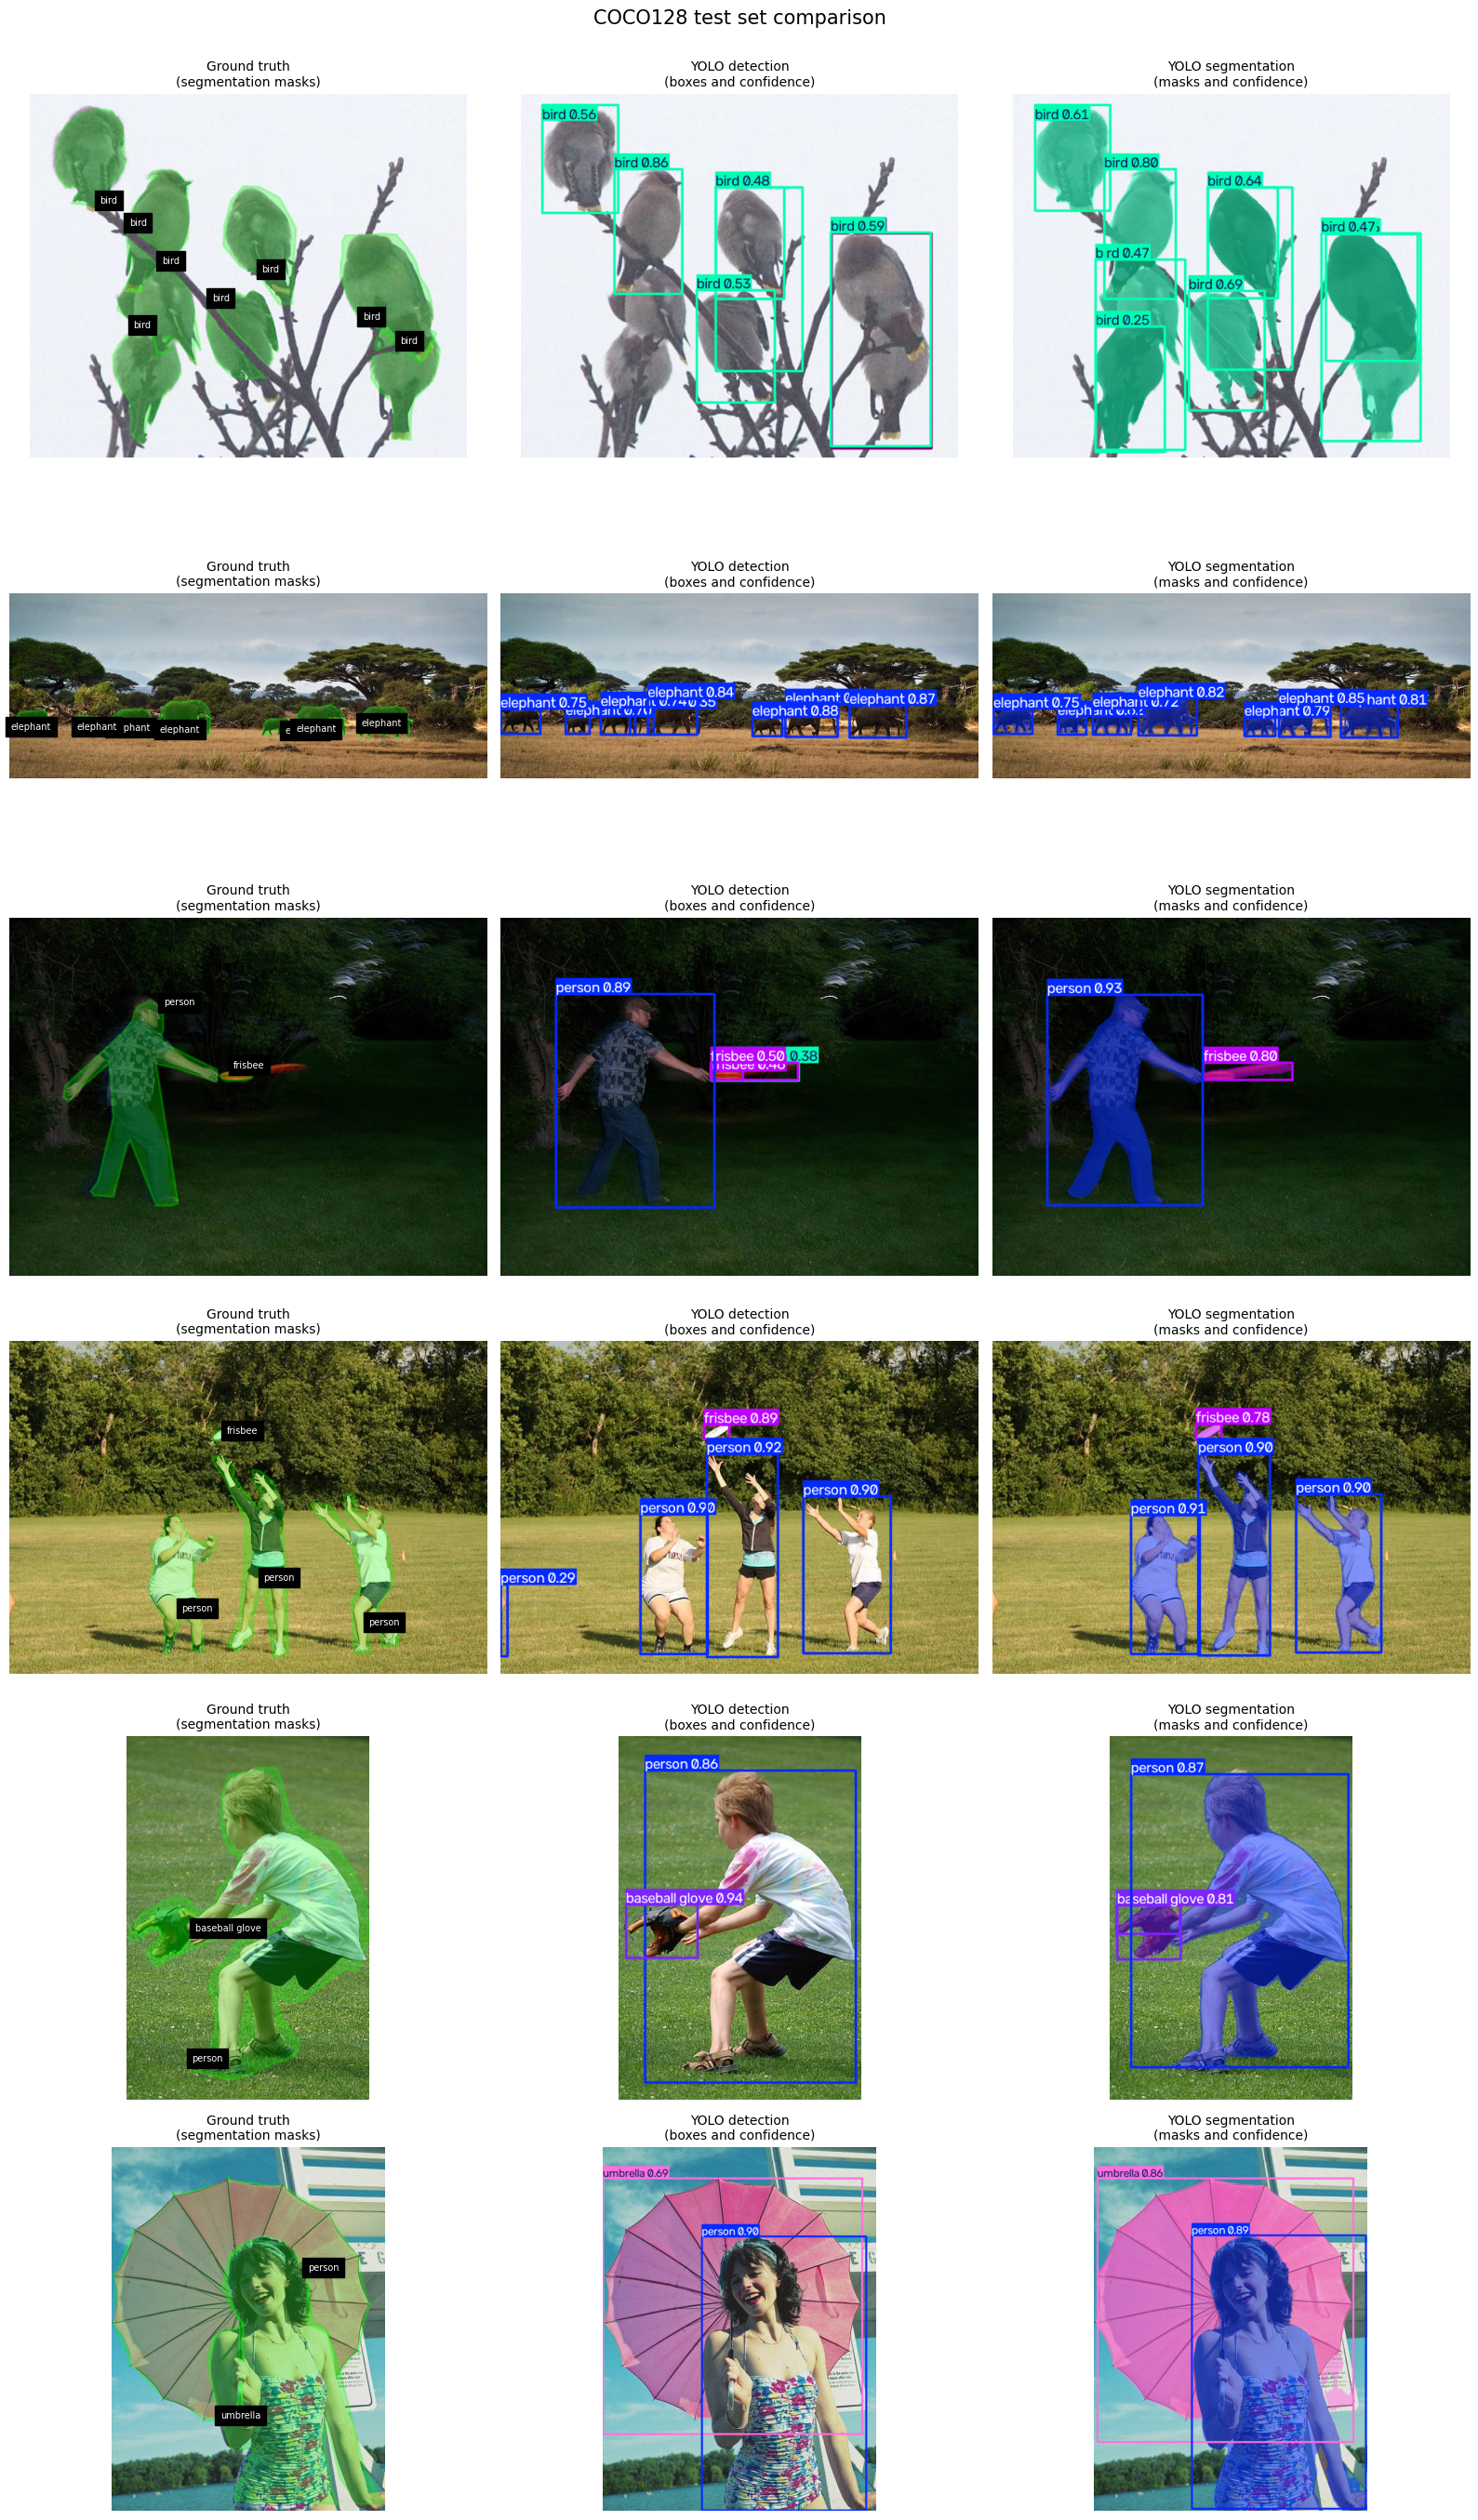

Evidencia visual guardada en: /content/evidencia_visual_COCO.png


In [16]:
from pathlib import Path
from IPython.display import display, Image as IPImage
import random

# Load the best saved weights when available.
# Otherwise, keep the current model.
det_best = Path("/content/runs/detect_train/weights/best.pt")
seg_best = Path("/content/runs/seg_train/weights/best.pt")

if det_best.exists():
    detector_visual = YOLO(str(det_best))
else:
    detector_visual = detector
    print("Warning: detection best.pt was not found; using the current model.")

if seg_best.exists():
    segmenter_visual = YOLO(str(seg_best))
else:
    segmenter_visual = segmenter
    print("Warning: segmentation best.pt was not found; using the current model.")


def draw_segmentation_ground_truth(ax, img_rgb, label_path, class_names):
    """Dibuja las máscaras y clases reales a partir de etiquetas YOLO-seg."""
    h, w = img_rgb.shape[:2]
    ax.imshow(img_rgb)

    if os.path.exists(label_path):
        with open(label_path, encoding="utf-8") as f:
            for line in f:
                parts = line.split()
                if len(parts) < 7:
                    continue

                cls = int(parts[0])
                coords = np.asarray(parts[1:], dtype=np.float32).reshape(-1, 2)
                coords[:, 0] *= w
                coords[:, 1] *= h

                polygon = patches.Polygon(
                    coords,
                    closed=True,
                    linewidth=1.8,
                    edgecolor="lime",
                    facecolor="lime",
                    alpha=0.25,
                )
                ax.add_patch(polygon)

                x_text, y_text = coords[0]
                class_name = class_names[cls] if cls < len(class_names) else str(cls)
                ax.text(
                    x_text,
                    max(y_text - 4, 0),
                    class_name,
                    fontsize=7,
                    color="white",
                    backgroundcolor="black",
                )

    ax.set_title("Ground truth\n(segmentation masks)", fontsize=10)
    ax.axis("off")


def plot_ultralytics_result(ax, result, title, show_masks):
    """Convierte la salida de Ultralytics a RGB y la despliega en Matplotlib."""
    rendered_bgr = result.plot(
        conf=True,
        labels=True,
        boxes=True,
        masks=show_masks,
    )
    rendered_rgb = cv2.cvtColor(rendered_bgr, cv2.COLOR_BGR2RGB)
    ax.imshow(rendered_rgb)
    ax.set_title(title, fontsize=10)
    ax.axis("off")


# MODIFICADO: Seleccionar imágenes aleatorias SIN semilla fija
SAMPLE_COUNT = min(6, len(TEST_FILES))
# Eliminamos random.seed() o comentamos la línea que usa SEED
chosen_images = random.sample(TEST_FILES, SAMPLE_COUNT)

print(f"Imágenes seleccionadas aleatoriamente ({SAMPLE_COUNT}):")
for img in chosen_images:
    print(f"  - {img}")

fig, axes = plt.subplots(SAMPLE_COUNT, 3, figsize=(16, 4.5 * SAMPLE_COUNT))
if SAMPLE_COUNT == 1:
    axes = np.expand_dims(axes, axis=0)

for row, img_name in enumerate(chosen_images):
    img_path = os.path.join(TEST_IMAGES, img_name)
    label_path = os.path.join(TEST_LABELS, Path(img_name).stem + ".txt")

    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f"No fue posible leer la imagen: {img_path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Column 1: ground truth.
    draw_segmentation_ground_truth(
        axes[row, 0], img_rgb, label_path, CLASS_NAMES
    )

    # Column 2: detection model.
    det_result = detector_visual.predict(
        source=img_path,
        conf=0.25,
        device=DEVICE,
        verbose=False,
    )[0]
    plot_ultralytics_result(
        axes[row, 1],
        det_result,
        "YOLO detection\n(boxes and confidence)",
        show_masks=False,
    )

    # Column 3: segmentation model.
    seg_result = segmenter_visual.predict(
        source=img_path,
        conf=0.25,
        device=DEVICE,
        verbose=False,
    )[0]
    plot_ultralytics_result(
        axes[row, 2],
        seg_result,
        "YOLO segmentation\n(masks and confidence)",
        show_masks=True,
    )

fig.suptitle(
    "COCO128 test set comparison",
    fontsize=15,
    y=1.002,
)
plt.tight_layout()

VISUAL_EVIDENCE_PATH = "/content/evidencia_visual_COCO.png"
fig.savefig(VISUAL_EVIDENCE_PATH, dpi=180, bbox_inches="tight")
plt.show()
plt.close(fig)

print(f"Evidencia visual guardada en: {VISUAL_EVIDENCE_PATH}")

Training graphs display the detection and segmentation result images.


Detection training


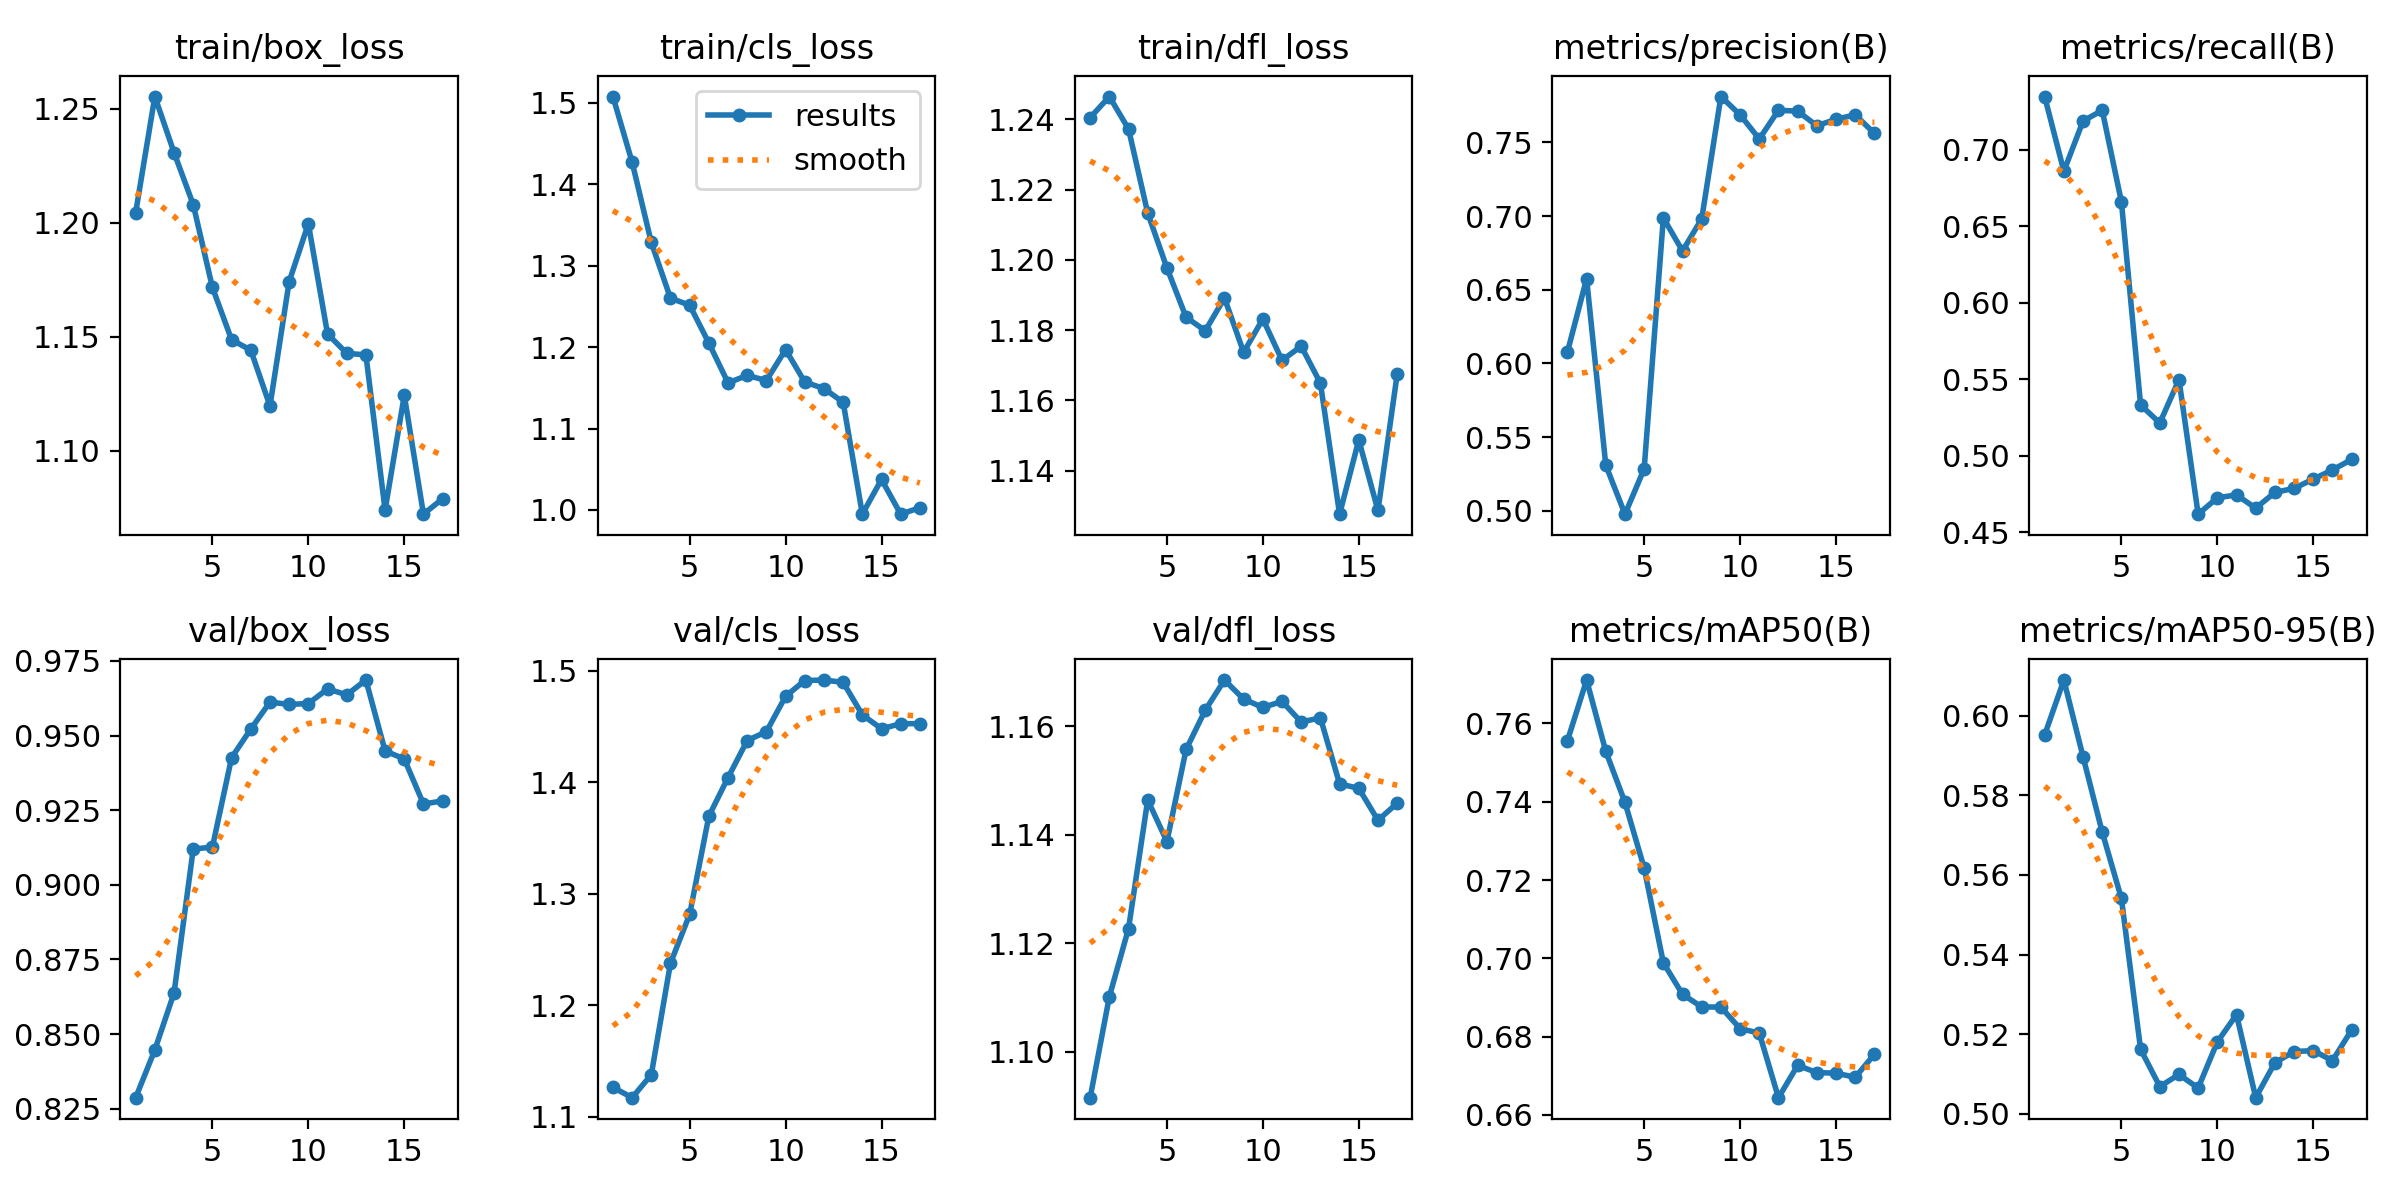


Segmentation training


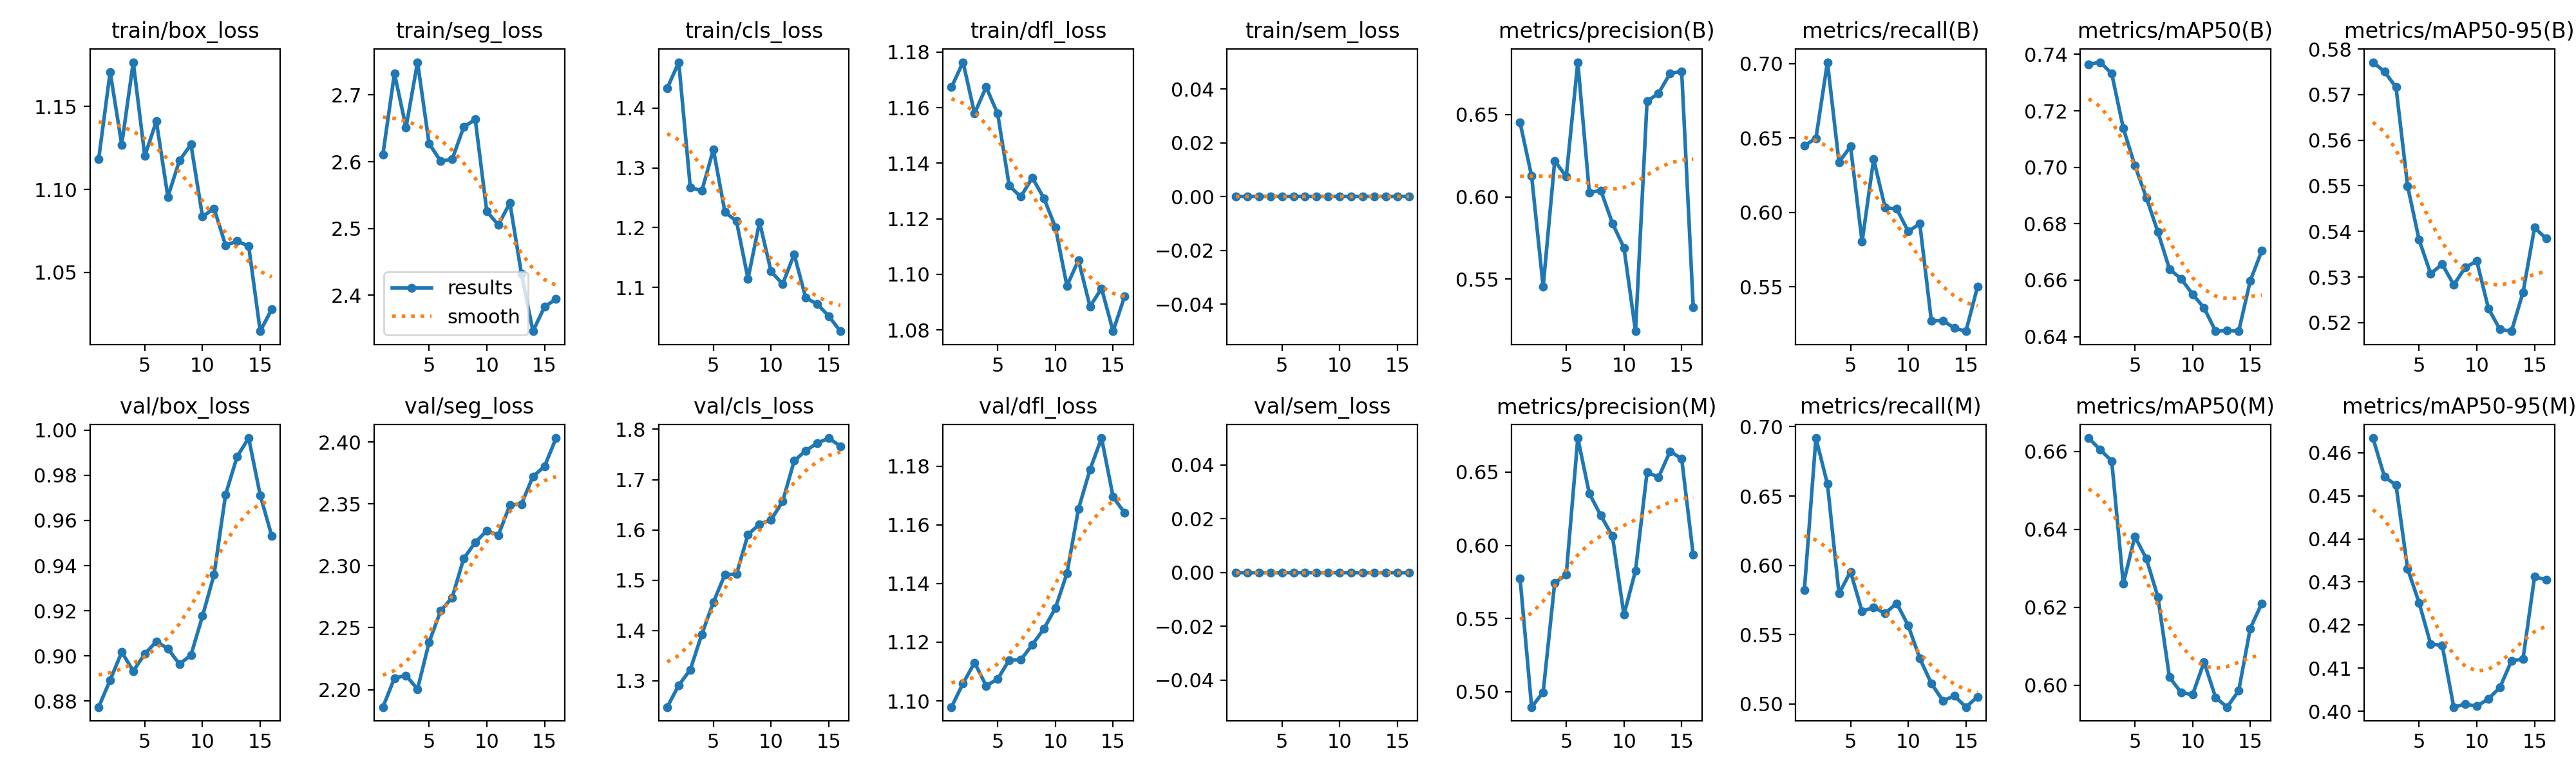

In [17]:
from IPython.display import display, Image as IPImage

TRAINING_PLOTS = {
    "Detection training": "/content/runs/detect_train/results.png",
    "Segmentation training": "/content/runs/seg_train/results.png",
}

for title, figure_path in TRAINING_PLOTS.items():
    print(f"\n{title}")
    if os.path.exists(figure_path):
        display(IPImage(filename=figure_path, width=1000))
    else:
        print(f"File not found {figure_path}. Check the Ultralytics run folder name.")


## 15. Conclusions

The laboratory completed an end-to-end YOLOv8 workflow for detection and instance segmentation.

The same image split was used for both tasks, and both models used transfer learning from COCO weights. Test metrics provide a numerical evaluation, while the final images provide a visual comparison.

The small COCO subset makes the experiment practical in Colab, although a larger dataset would normally provide more information for training.